In [1]:
import numpy as np




In [2]:
x=np.array([2])
w=np.array([3])
y=x**2
y+=1






x

array([2])

In [3]:
d1 = {1: 1, 2: 2}
d2 = {4: 'ha!', 3: 3}
d1['d2'] = d2
d1


{1: 1, 2: 2, 'd2': {4: 'ha!', 3: 3}}

In [4]:
import torch
t=torch.tensor([[2,2,4],[1,1,9]])
t=t.unsqueeze(2)
t=t.unsqueeze(3)
t=t.repeat((1,1,3,3))
t.shape

torch.Size([2, 3, 3, 3])

In [5]:
t=torch.tensor([[1,0,0],[0,1,0],[0,0,1],[0,1,0],[0,0,1],[0,0,1],[1,0,0],[0,1,0],[1,0,0],[0,1,0],[0,0,1],[0,1,0],[0,0,1],[0,0,1],[1,0,0],[0,1,0]])

In [6]:
t

tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0]])

In [7]:
x=t[:,0]==1
i=x.nonzero().squeeze().tolist()
i


[0, 6, 8, 14]

In [8]:
m=t.shape[1]
L=[]
i=t.nonzero()
for j in range(m):
    l=i[i[:,1]==j][:,0].tolist()
    print(l)
    L.append(l)
print(L)


[0, 6, 8, 14]
[1, 3, 7, 9, 11, 15]
[2, 4, 5, 10, 12, 13]
[[0, 6, 8, 14], [1, 3, 7, 9, 11, 15], [2, 4, 5, 10, 12, 13]]


In [9]:
from numpy import linalg as LA
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

#all parents
P3=Pin+Pin2
P3[P3!=0]=1
print(P3)

pr=1/2


E=W**2
needs=E@P3
needs=np.sqrt((needs))
print(needs)
row_l2_norm = LA.norm(W[:,[0,1,3]], axis=1)
print(row_l2_norm)

total=needs.shape[0]*needs.shape[1]
keep=(1-pr)*total
aligned_keep=needs.shape[0]
misaligned_keep=keep-aligned_keep
misaligned_total=total-aligned_keep
apr=misaligned_keep/total
print(total,keep,aligned_keep,misaligned_keep,misaligned_total,apr)

c2=1-Pout
print("c2", c2)
res1=needs*c2
print("res1", res1)
t=torch.quantile(torch.from_numpy(res1), 1-apr).item()
print(t)
res1[res1>t]=1
res1[res1!=1]=0
print(res1)
res1=res1+Pout
print(res1)
mask=res1@np.transpose(P3)
mask[mask!=0]=1
print(mask)






[[1 0 1]
 [1 1 0]
 [0 1 1]
 [1 0 0]]
[[ 6.55743852  5.          5.        ]
 [10.          7.          9.21954446]
 [14.2126704  13.45362405 10.        ]
 [17.69180601 13.         12.        ]]
[ 6.55743852 10.         14.2126704  17.69180601]
12 6.0 4 2.0 8 0.16666666666666666
c2 [[1 0 1]
 [1 0 1]
 [1 1 0]
 [0 1 1]]
res1 [[ 6.55743852  0.          5.        ]
 [10.          0.          9.21954446]
 [14.2126704  13.45362405  0.        ]
 [ 0.         13.         12.        ]]
13.07560400784562
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 0.]
 [0. 0. 0.]]
[[0. 1. 0.]
 [0. 1. 0.]
 [1. 1. 1.]
 [1. 0. 0.]]
[[0. 1. 1. 0.]
 [0. 1. 1. 0.]
 [1. 1. 1. 1.]
 [1. 1. 0. 1.]]


In [10]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[1,0],
[0,1],
[1,0],
[1,0]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0,1],
[0,1],
[1,0],
[1,0]])


needs=E@Pin
print(needs)
needs[needs!=0]=1
a=1
#needs=torch.tanh(torch.from_numpy(a*needs)).numpy()
#needs=pnormalize(needs)
print(needs)
costs=Pout@C
print(costs)

res2=needs*costs
print(np.sum(res2))


[[3 1]
 [3 0]
 [2 1]
 [1 1]]
[[1 1]
 [1 0]
 [1 1]
 [1 1]]
[[ 7  0]
 [ 7  0]
 [ 0 19]
 [ 0 19]]
52


In [11]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[1,0],
[0,1],
[1,0],
[1,0]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0,1],
[0,1],
[1,0],
[1,0]])


needs=E@Pin
print(needs)
needs[needs!=0]=1
a=1
#needs=torch.tanh(torch.from_numpy(a*needs)).numpy()
#needs=pnormalize(needs)
print(needs)
costs=C
print(costs)

res2=needs@costs
print(res2)


[[3 1]
 [3 0]
 [2 1]
 [1 1]]
[[1 1]
 [1 0]
 [1 1]
 [1 1]]
[[ 0 19]
 [ 7  0]]
[[ 7 19]
 [ 0 19]
 [ 7 19]
 [ 7 19]]


In [12]:
import matplotlib.pyplot as plt
def ppp(f):
    # Create an array of x values
    x = np.linspace(0, 10, 1000)
    a=20
    # Calculate the PDF for each x value
    pdf = torch.tanh(torch.from_numpy(a*x)).numpy()

    # Plot the PDF
    plt.plot(x, pdf)
    plt.show()

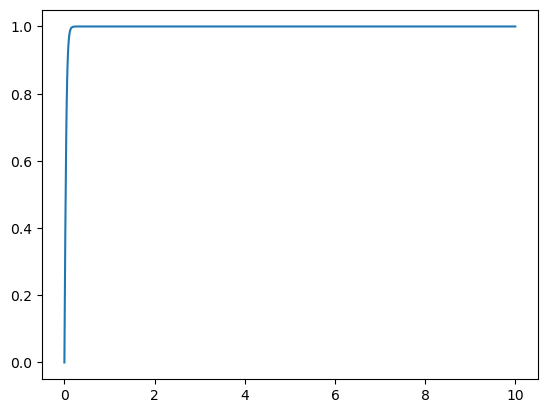

In [13]:
f=torch.tanh
ppp(f)

In [14]:
def softmax(x):
    """
    Computes the softmax function for a given numpy array.

    Args:
        x (numpy.ndarray): Input array.

    Returns:
        numpy.ndarray: Softmax output.
    """
    e_x = np.exp((x - np.max(x))) # Subtracting np.max(x) for numerical stability
    return e_x / e_x.sum(axis=0)

In [15]:
def pnormalize(x,p=2):
    """
    Computes the softmax function for a given numpy array.

    Args:
        x (numpy.ndarray): Input array.

    Returns:
        numpy.ndarray: Softmax output.
    """
    e_x = x**p # Subtracting np.max(x) for numerical stability
    return e_x #/ e_x.sum(axis=0)

In [16]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[0.8,0.2],
[0.2,0.8],
[0.8,0.2],
[0.8,0.2]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0.2,0.8],
[0.2,0.8],
[0.8,0.2],
[0.8,0.2]])


needs=E@Pin
print(needs)
#needs[needs!=0]=1
needs=pnormalize(needs)

print(needs)
costs=Pout@C
print(costs)

res2=needs*costs
print(np.sum(res2,axis=1))


[[2.6 1.4]
 [2.4 0.6]
 [1.8 1.2]
 [1.  1. ]]
[[6.76 1.96]
 [5.76 0.36]
 [3.24 1.44]
 [1.   1.  ]]
[[ 5.6  3.8]
 [ 5.6  3.8]
 [ 1.4 15.2]
 [ 1.4 15.2]]
[45.304 33.624 26.424 16.6  ]


## Create topolgies

In [17]:
import numpy as np
import topologies
import networkx as nx
import yaml
import json

In [18]:
def create_maps_from_E(N,E):
    maps=np.full((N,N),10e10) #  99
    #maps=np.full((N,N),99) #  99
    for i in range(N):
        maps[i,i]=0
    for (i,j,v) in E:
        maps[i,j]=v
        maps[j,i]=v
    return maps


In [19]:
model_type = 'resnet18' # valid: resnet18, resnet101
experiment_name = 'ServiceNetwork' # valid: GEANT, Dtelekom, Abilene, ServiceNetwork

if experiment_name == 'GEANT':
    graph = topologies.GEANT()
if experiment_name == 'Dtelekom':
    graph = topologies.Dtelekom()
if experiment_name == 'Abilene':
    graph = topologies.Abilene()
if experiment_name == 'ServiceNetwork':
    graph = topologies.ServiceNetwork()

In [20]:
print(graph.number_of_nodes())
N = graph.number_of_nodes()
print(graph.number_of_edges())
print(list(graph.nodes))
print(list(graph.edges))


8
7
['CHAIN1', 'CHAIN2', 'CHAIN3', 'CHAIN4', 'CONSUMER1', 'CONSUMER2', 'CONSUMER3', 'CONSUMER4']
[('CHAIN1', 'CHAIN2'), ('CHAIN2', 'CHAIN3'), ('CHAIN3', 'CHAIN4'), ('CHAIN4', 'CONSUMER1'), ('CHAIN4', 'CONSUMER2'), ('CHAIN4', 'CONSUMER3'), ('CHAIN4', 'CONSUMER4')]


In [21]:
mapping = {}
i = 0
for node in list(graph.nodes):
    #print(node)
    mapping[node] = i
    i = i + 1
print(mapping)


{'CHAIN1': 0, 'CHAIN2': 1, 'CHAIN3': 2, 'CHAIN4': 3, 'CONSUMER1': 4, 'CONSUMER2': 5, 'CONSUMER3': 6, 'CONSUMER4': 7}


In [22]:
new_graph= nx.relabel_nodes(graph, mapping)
print(list(new_graph.nodes))
print(list(new_graph.edges))
nodes = list(new_graph.nodes)
edges = list(new_graph.edges)

[0, 1, 2, 3, 4, 5, 6, 7]
[(0, 1), (1, 2), (2, 3), (3, 4), (3, 5), (3, 6), (3, 7)]


In [23]:
E = []
y = (1,)
for edge in edges:
    edge += y
    E.append(edge)
print(E)

[(0, 1, 1), (1, 2, 1), (2, 3, 1), (3, 4, 1), (3, 5, 1), (3, 6, 1), (3, 7, 1)]


In [24]:
#N=4
#E=[(0,1,1),(0,2,4),(2,3,1),(0,3,1)]
maps = create_maps_from_E(N,E)
maps


array([[0.e+00, 1.e+00, 1.e+11, 1.e+11, 1.e+11, 1.e+11, 1.e+11, 1.e+11],
       [1.e+00, 0.e+00, 1.e+00, 1.e+11, 1.e+11, 1.e+11, 1.e+11, 1.e+11],
       [1.e+11, 1.e+00, 0.e+00, 1.e+00, 1.e+11, 1.e+11, 1.e+11, 1.e+11],
       [1.e+11, 1.e+11, 1.e+00, 0.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00],
       [1.e+11, 1.e+11, 1.e+11, 1.e+00, 0.e+00, 1.e+11, 1.e+11, 1.e+11],
       [1.e+11, 1.e+11, 1.e+11, 1.e+00, 1.e+11, 0.e+00, 1.e+11, 1.e+11],
       [1.e+11, 1.e+11, 1.e+11, 1.e+00, 1.e+11, 1.e+11, 0.e+00, 1.e+11],
       [1.e+11, 1.e+11, 1.e+11, 1.e+00, 1.e+11, 1.e+11, 1.e+11, 0.e+00]])

In [25]:
# valid: resnet18, resnet101
if model_type == 'resnet18':
    layers_str = "[inputs, conv1.weight, layer1.0.conv1.weight, layer1.0.conv2.weight, layer1.1.conv1.weight, layer1.1.conv2.weight, layer2.0.conv1.weight, layer2.0.conv2.weight, layer2.0.shortcut.0.weight, layer2.1.conv1.weight, layer2.1.conv2.weight, layer3.0.conv1.weight, layer3.0.conv2.weight, layer3.0.shortcut.0.weight, layer3.1.conv1.weight, layer3.1.conv2.weight, layer4.0.conv1.weight, layer4.0.conv2.weight, layer4.0.shortcut.0.weight, layer4.1.conv1.weight, layer4.1.conv2.weight]"

In [26]:
yaml_dict = {}
yaml_dict['bn_partitions'] = [N] * 9
initial_budget = [1] * N
yaml_dict['budgets'] = np.tile(initial_budget, (20, 1)).tolist()
yaml_dict['initial_budget'] = initial_budget
yaml_dict['input_partition'] = initial_budget
yaml_dict['layers'] = layers_str
yaml_dict['maps'] = maps.tolist() #np.array2string(maps, threshold=10000)
yaml_dict['num'] = N
yaml_str = json.dumps(yaml_dict)

yaml_str = yaml_str.replace("\"", "")
yaml_str = yaml_str.replace(", budgets: ", "\nbudgets: ")
yaml_str = yaml_str.replace(", initial_budget: ", "\ninitial_budget: ")
yaml_str = yaml_str.replace(", input_partition: ", "\ninput_partition: ")
yaml_str = yaml_str.replace(", layers: ", "\nlayers: ")
yaml_str = yaml_str.replace(", maps: ", "\nmaps: ")
yaml_str = yaml_str.replace(", num: ", "\nnum: ")
yaml_str = yaml_str.replace("{", "")
yaml_str = yaml_str.replace("}", "")
'''
yaml_str = yaml_str.replace(", '", "\n'")
yaml_str = yaml_str.replace("{", "")
yaml_str = yaml_str.replace("}", "")
yaml_str = yaml_str.replace("array(", "")
yaml_str = yaml_str.replace("]])", "]]")
yaml_str = yaml_str.replace("],", "]\n")
'''
yaml_str = yaml_str.replace("layer1.1.conv1.weight,", "layer1.1.conv1.weight,\n")
yaml_str = yaml_str.replace("layer2.0.shortcut.0.weight,", "layer2.0.shortcut.0.weight,\n")
yaml_str = yaml_str.replace("layer3.0.conv2.weight,", "layer3.0.conv2.weight,\n")
yaml_str = yaml_str.replace("layer4.0.conv1.weight,", "layer4.0.conv1.weight,\n")

yaml_str = yaml_str.replace("layer1.1.conv2.weight,", "        layer1.1.conv2.weight,")
yaml_str = yaml_str.replace("layer2.1.conv1.weight,", "        layer2.1.conv1.weight,")
yaml_str = yaml_str.replace("layer3.0.shortcut.0.weight,", "        layer3.0.shortcut.0.weight,")
yaml_str = yaml_str.replace("layer4.0.conv2.weight", "        layer4.0.conv2.weight")
'''
yaml_str = yaml_str.replace("\"", "")
yaml_str = yaml_str.replace(", maps: ", "\nmaps: ")
'''

new_graph.nodes

yaml_filename = "./config/resnet18-np" + str(len(new_graph.nodes)) + "-" + experiment_name + ".yaml"
print(yaml_filename)
with open(yaml_filename, 'w') as file:
    file.write(yaml_str)
print(yaml_str)


./config/resnet18-np8-ServiceNetwork.yaml
bn_partitions: [8, 8, 8, 8, 8, 8, 8, 8, 8]
budgets: [[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]]
initial_budget: [1, 1, 1, 1, 1, 1, 1, 1]
input_partition: [1, 1, 1, 1, 1, 1, 1, 1]
layers: [inputs, conv1.weight, layer1.0.conv1.weight, layer1.0.conv2.weight, layer1.1.conv1.weight,
         layer1.1.conv2.weight, layer2.0.conv1.weight, layer2.0.conv2.weight, layer2.0.shortcut.0.weight,
         layer2.1.conv1.weight, layer2.1.conv2.weight, layer3.0.conv1.weight, layer3.0.conv2.wei

In [27]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from plottable import Table

In [28]:
from pareto import *

Files already downloaded and verified
Files already downloaded and verified


/home/davarakis.t/.conda/envs/newcap/lib/python3.12/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/home/davarakis.t/proect2/CaP2/pareto.py:935: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functi

accuracy, comm_cost, eval_cost, eval_cost_aggregate:  91.22 1191936 14246736.0 607248.0
accuracy, comm_cost, eval_cost, eval_cost_aggregate:  91.34 1191936 5662016.0 343808.0
accuracy, comm_cost, eval_cost, eval_cost_aggregate:  91.16 2608896 16303840.0 923680.0
accuracy, comm_cost, eval_cost, eval_cost_aggregate:  70.72 1.3310240000210894e+17 1.202433612717228 1.010767896814551
accuracy, comm_cost, eval_cost, eval_cost_aggregate:  53.9 1.1152320000092226e+17 1.5598959754624369 1.991903783461847
accuracy, comm_cost, eval_cost, eval_cost_aggregate:  33.53 1.0921440000087882e+17 1.6359471331714006 2.029216225946501
accuracy, comm_cost, eval_cost, eval_cost_aggregate:  89.0 866304 19879760.0 1011696.0
accuracy, comm_cost, eval_cost, eval_cost_aggregate:  89.04 866304 8727040.0 308480.0
accuracy, comm_cost, eval_cost, eval_cost_aggregate:  85.83 1944480 19175216.0 1376784.0
accuracy, comm_cost, eval_cost, eval_cost_aggregate:  87.0 737360 5448864.0 295888.0
accuracy, comm_cost, eval_cost, 

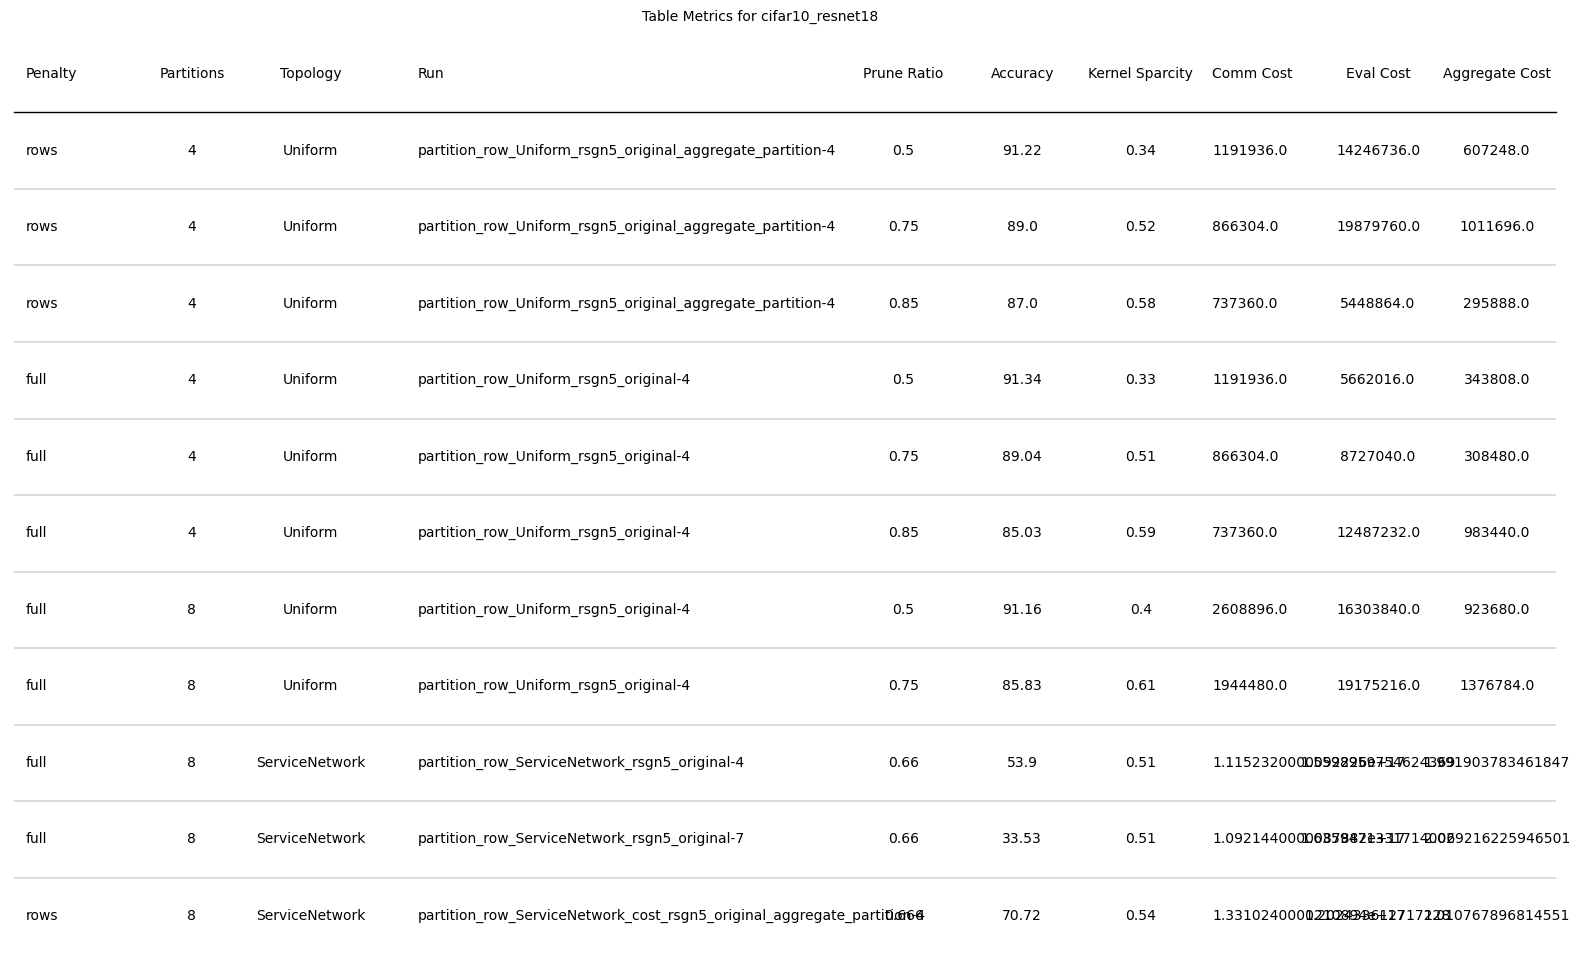

In [29]:
experiment_logs_path = "experiment_logs"
code = "cifar10"
dataset_root = "./assets/data"
experiments = generate_visualizations(experiment_logs_path, code, dataset_root, gen_images=False, sparsity_mode="kernel")
#experiments

In [30]:
topologies = []
penalties = []
partitions = []
exp_runs = []
prune_ratios = []
accuracies = []
comm_costs = []
eval_costs = []
eval_cost_aggregates = []
kernel_sparcities = []

for key, reassignments in experiments.items():
    print(key)
    partition = key[2]
    penalty = key[3]
    print(partition, penalty)
    for idx, (reassign_flag, runs) in enumerate(reassignments.items()):
      print(reassign_flag)
      first_split = reassign_flag.split("-")
      admm_epochs = first_split[1]
      second_split = reassign_flag.split("_")
      topology = second_split[2]
      for run in runs:
        #print("-----------------")
        print(run)
        partitions.append(partition)
        penalties.append(penalty)
        exp_runs.append(reassign_flag)
        prune_ratios.append(run[0])
        accuracies.append(run[1])
        comm_costs.append(run[2])
        eval_costs.append(run[6])
        eval_cost_aggregates.append(run[7])
        kernel_sparcities.append(run[5])
        topologies.append(topology)      

AttributeError: 'NoneType' object has no attribute 'items'

In [ ]:
print(len(penalties))
print(len(partitions))
print(len(exp_runs))
print(len(prune_ratios))
print(len(accuracies))
print(len(topologies))


9
9
9
9
9
9


In [ ]:
penalties= ['full', 'full', 'full', 'full', 'full', 'full', 'full']
partitions= ['4', '4', '4', '8', '8', '8', '8']
topologies= ['Uniform', 'Uniform', 'Uniform', 'Uniform', 'Uniform', 'ServiceNetwork', 'ServiceNetwork']
exp_runs=  ['partition_row_Uniform_rsgn5_original-4', 'partition_row_Uniform_rsgn5_original-4', 'partition_row_Uniform_rsgn5_original-4', 'partition_row_Uniform_rsgn5_original-4', 'partition_row_Uniform_rsgn5_original-4', 'partition_row_ServiceNetwork_rsgn5_original-4', 'partition_row_ServiceNetwork_rsgn5_original-7']
prune_ratios=[0.5, 0.75, 0.85, 0.5, 0.75, 0.66, 0.66]
accuracies= [91.34, 89.04, 85.03, 91.16, 85.83, 53.9, 33.53]
kernel_sparcities=[0.33, 0.50, 0.58, 0.39, 0.61, 0.51, 0.51]
comm_costs= [1191936, 866304, 737360, 2608896, 1944480, 11152320, 1092144000]
eval_costs=[5662016.0, 8727040.0, 12487232.0, 16303840.0, 19175216.0, 15598959, 635947133]
eval_cost_aggregates=[343808.0, 308480.0, 983440.0, 923680.0, 1376784.0, 1991903, 2029216225]

In [ ]:
dict = {'Penalty': penalties, 'Partitions': partitions, 'Topology': topologies, 
      'Run': exp_runs, 'Prune Ratio': prune_ratios, 'Accuracy': accuracies, 'Kernel Sparcity': kernel_sparcities, 
      'Comm Cost': comm_costs, 'Eval Cost': eval_costs, 'Aggregate Cost': eval_cost_aggregates} 
#print(dict)
df = pd.DataFrame(dict)
df = df.set_index("Penalty")
df


,Partitions,Topology,Run,Prune Ratio,Accuracy,Kernel Sparcity,Comm Cost,Eval Cost,Aggregate Cost
Penalty,,,,,,,,,
full,4,Uniform,partition_row_Uniform_rsgn5_original-4,0.50,91.34,0.33,1191936,5662016.0,3.438080e+05
full,4,Uniform,partition_row_Uniform_rsgn5_original-4,0.75,89.04,0.50,866304,8727040.0,3.084800e+05
full,4,Uniform,partition_row_Uniform_rsgn5_original-4,0.85,85.03,0.58,737360,12487232.0,9.834400e+05
full,8,Uniform,partition_row_Uniform_rsgn5_original-4,0.50,91.16,0.39,2608896,16303840.0,9.236800e+05
full,8,Uniform,partition_row_Uniform_rsgn5_original-4,0.75,85.83,0.61,1944480,19175216.0,1.376784e+06
full,8,ServiceNetwork,partition_row_ServiceNetwork_rsgn5_original-4,0.66,53.90,0.51,11152320,15598959.0,1.991903e+06
full,8,ServiceNetwork,partition_row_ServiceNetwork_rsgn5_original-7,0.66,33.53,0.51,1092144000,635947133.0,2.029216e+09


In [ ]:
colnames = [
    "Penalty",
    "Partitions",
    "Topology",
    "Run",
    "Prune Ratio",
    "Accuracy",
    "Comm Cost",
    "Eval Cost",
    "Aggregate Cost",
    "Kernel Sparcity",
]

In [ ]:
from plottable import ColumnDefinition, Table

In [ ]:
col_defs = (
    [
        ColumnDefinition(
            name="Penalty",
            textprops={"ha": "left"},
            width=0.75,
        ),
        ColumnDefinition(
            name="Partitions",
            textprops={"ha": "center"},
            width=0.75,
        ),
        ColumnDefinition(
            name="Topology",
            #group="Team Rating",
            textprops={"ha": "center"},
            width=0.75,
        ),
        ColumnDefinition(
            name="Run",
            textprops={"ha": "left"},
            width=3,
        ),
        ColumnDefinition(
            name="Prune Ratio",
            textprops={"ha": "center"},
            width=0.75,
        ),
        ColumnDefinition(
            name="Accuracy",
            #group="Team Rating",
            textprops={"ha": "center"},
            width=0.75,
        ),
        ColumnDefinition(
            name="Comm Cost",
            textprops={"ha": "left"},
            width=0.75,
        ),
        ColumnDefinition(
            name="Aggregate Cost",
            textprops={"ha": "center"},
            width=0.75,
        ),
        ColumnDefinition(
            name="Eval Cost",
            #group="Team Rating",
            textprops={"ha": "center"},
            width=0.75,
        ),
        ColumnDefinition(
            name="Kernel Sparcity",
            #group="Team Rating",
            textprops={"ha": "center"},
            width=0.75,
        ),
    ]
)

In [ ]:
plt.rcParams["font.family"] = ["DejaVu Sans"]
plt.rcParams["savefig.bbox"] = "tight"

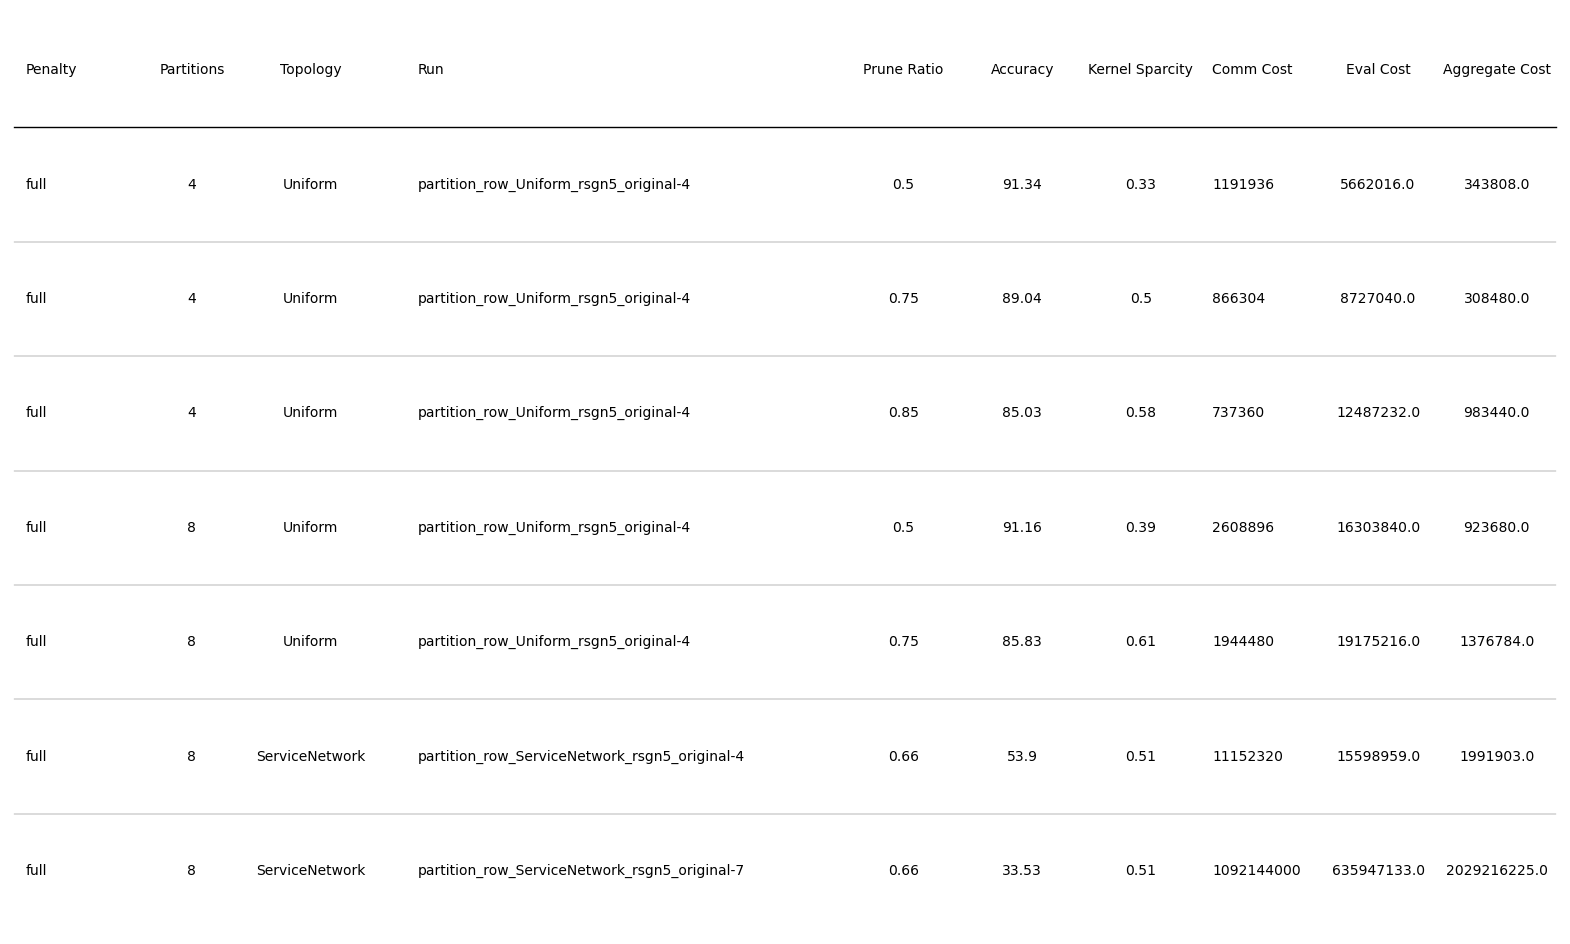

In [ ]:
fig, ax = plt.subplots(figsize=(20, 12))

table = Table(
    df,
    column_definitions=col_defs,
    #row_dividers=True,
    #footer_divider=True,
    ax=ax,
    textprops={"fontsize": 10},
    #row_divider_kw={"linewidth": 0.5, "linestyle": (0, (1, 5))},
    #col_label_divider_kw={"linewidth": 0.5, "linestyle": "-"},
    #column_border_kw={"linewidth": 0.5, "linestyle": "-"},
)#.autoset_fontcolors(colnames=["OFF", "DEF"])

fig.savefig("wwc_table.png", facecolor=ax.get_facecolor(), dpi=200)

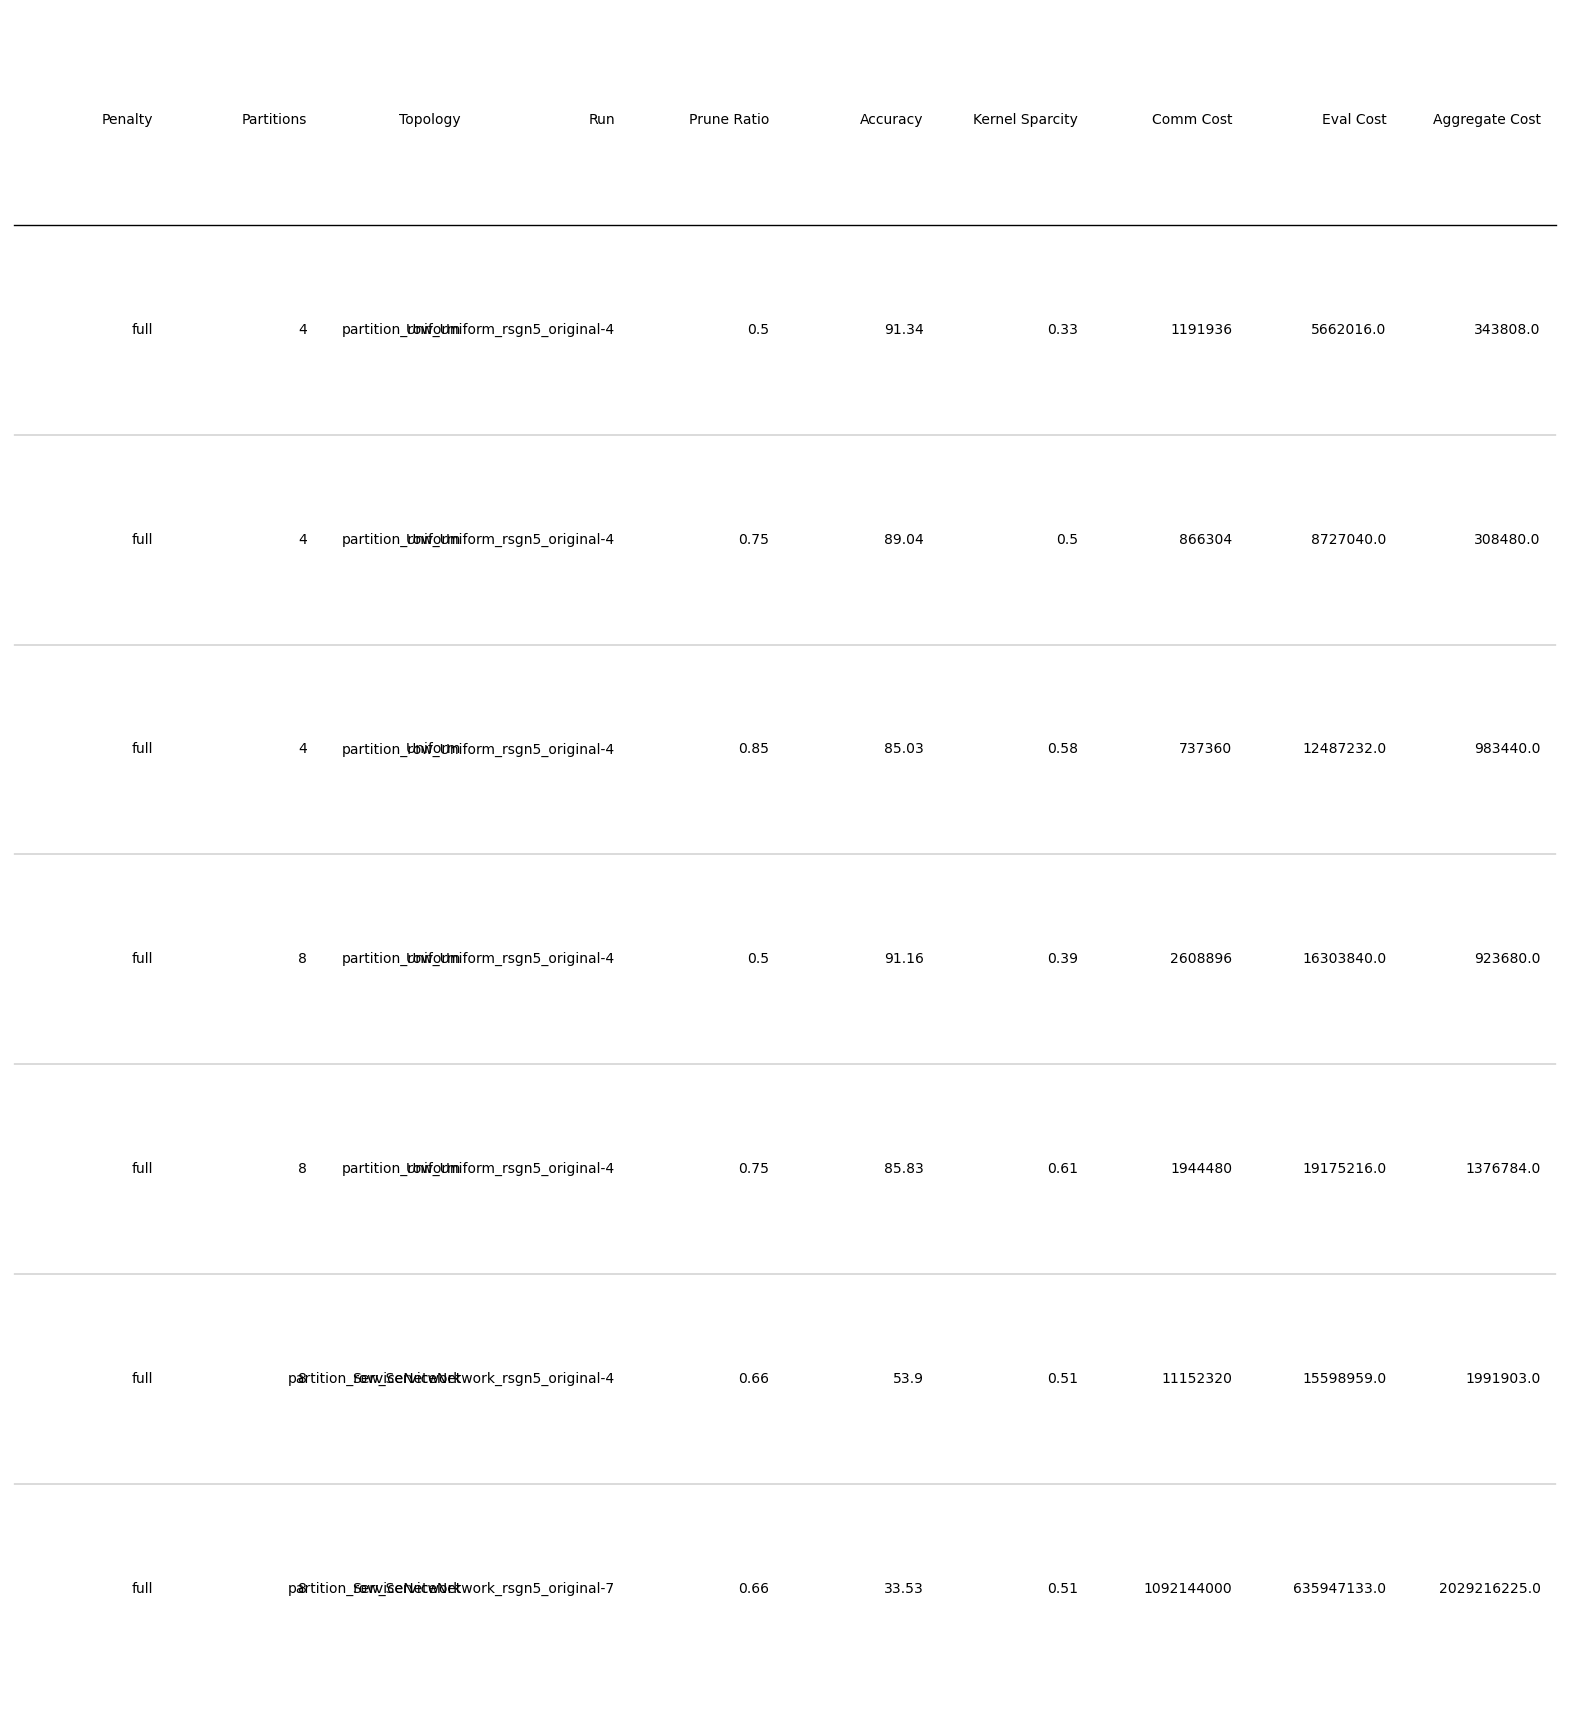

In [ ]:
fig, ax = plt.subplots(figsize=(20, 22))

tab = Table(    
    df,

    )

plt.show()

fig.savefig("basic_table.png")

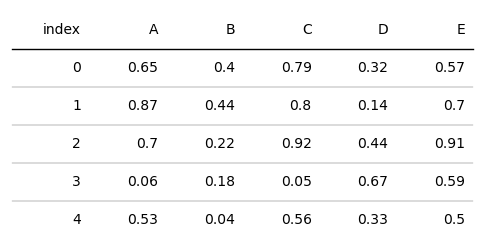

In [ ]:
d = pd.DataFrame(np.random.random((5, 5)), columns=["A", "B", "C", "D", "E"]).round(2)

fig, ax = plt.subplots(figsize=(6, 3))

tab = Table(d)

plt.show()

fig.savefig("experiment_logs/basic_table.png")

In [31]:
budget = [0,0,0,0.2,0.2,0.2,0.2,0.2]
shape = 64

In [43]:
def fixsum(a,shape):
    total=np.sum(a)
    dif=shape-total
    d=np.sign(dif)
    c=0
    for i in range(a.size):
        if c>=np.abs(dif):
            break
        if a[i]!=0:
            a[i]+=d
            c+=1
    return a

In [44]:
absolute_counts = np.round(np.array(budget) * shape).astype(int)
a=fixsum(absolute_counts,shape)

In [46]:
absolute_counts

array([ 0,  0,  0, 12, 13, 13, 13, 13])